# Quantitative Financial Analysis (AAPL)

## Technical Indicator Analysis

This notebook performs quantitative analysis on historical Apple Inc. (AAPL) stock price data using technical indicators and financial metrics.

The analysis focuses on understanding price behavior, momentum, trend direction, and volatility using professional-grade financial visualizations.

### Dataset Used:
- AAPL (Apple Inc.) historical stock price data (AAPL.csv)

### Includes:
- Data cleaning and preprocessing  
- SMA & EMA trend analysis  
- RSI momentum detection  
- MACD trend reversal signals  
- Volatility vs price behavior  
- Enhanced financial visualizations  

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import talib

plt.style.use('ggplot')

# Data Cleaning and Preprocessing

We clean and prepare the dataset for technical analysis by:
- Converting date column
- Sorting data chronologically
- Ensuring numeric consistency
- Removing missing values

In [3]:
df = pd.read_csv('../data/raw/yfinance_data/Data/AAPL.csv')
df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


# Dataset Overview

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3774 non-null   str    
 1   Close   3774 non-null   float64
 2   High    3774 non-null   float64
 3   Low     3774 non-null   float64
 4   Open    3774 non-null   float64
 5   Volume  3774 non-null   int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 177.0 KB


In [5]:
df.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')

In [6]:
df.isnull().sum()

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

# Data Cleaning

In [7]:
# Sort data
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# Numeric conversion
cols = ['Open','High','Low','Close','Volume']
for c in cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# Remove nulls
df = df.dropna()

# Moving Averages (Trend Analysis)

In [8]:
df['SMA_20'] = talib.SMA(df['Close'], 20)
df['SMA_50'] = talib.SMA(df['Close'], 50)

# Exponential Moving Averages

In [9]:
df['EMA_20'] = talib.EMA(df['Close'], 20)
df['EMA_50'] = talib.EMA(df['Close'], 50)

# Momentum Analysis — RSI

RSI is used to detect overbought and oversold market conditions.

In [10]:
df['RSI'] = talib.RSI(df['Close'], 14)

# Momentum & Trend Reversal — MACD

MACD helps identify trend direction changes and momentum shifts.

In [11]:
macd, signal, hist = talib.MACD(df['Close'], 12, 26, 9)
df['MACD'] = macd
df['MACD_SIGNAL'] = signal
df['MACD_HIST'] = hist

# Returns & Volatility

In [12]:
df['Daily_Return'] = df['Close'].pct_change()
df['Volatility'] = df['Daily_Return'].rolling(20).std()

In [17]:
# Export cleaned dataset
df.to_csv('../data/raw/AAPL_cleaned.csv', index=False)

# Price Action with SMA & EMA (Enhanced)

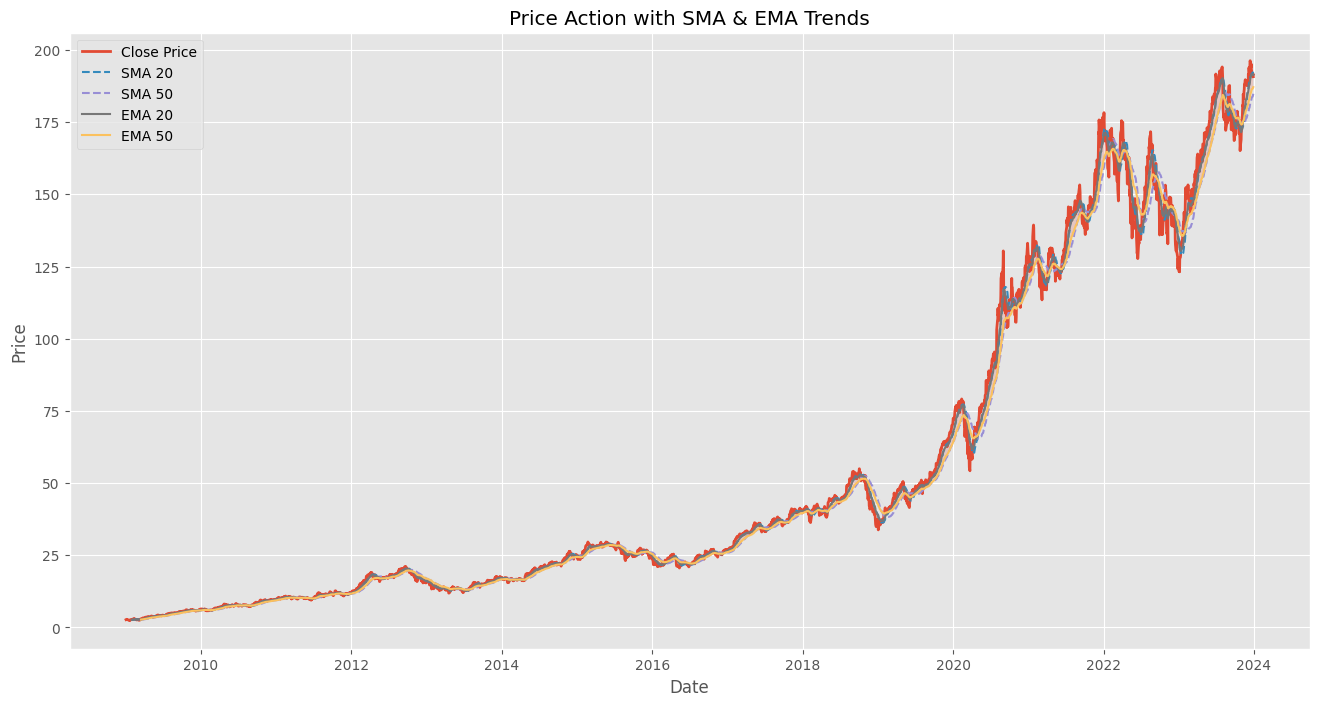

In [13]:
plt.figure(figsize=(16,8))

plt.plot(df['Date'], df['Close'], label='Close Price', linewidth=2)
plt.plot(df['Date'], df['SMA_20'], label='SMA 20', linestyle='--')
plt.plot(df['Date'], df['SMA_50'], label='SMA 50', linestyle='--')
plt.plot(df['Date'], df['EMA_20'], label='EMA 20')
plt.plot(df['Date'], df['EMA_50'], label='EMA 50')

# bullish zone
bull = df[df['EMA_20'] > df['EMA_50']]
plt.fill_between(bull['Date'], bull['EMA_20'], bull['EMA_50'], alpha=0.2)

plt.title('Price Action with SMA & EMA Trends')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

# RSI Analysis (Overbought/Oversold)

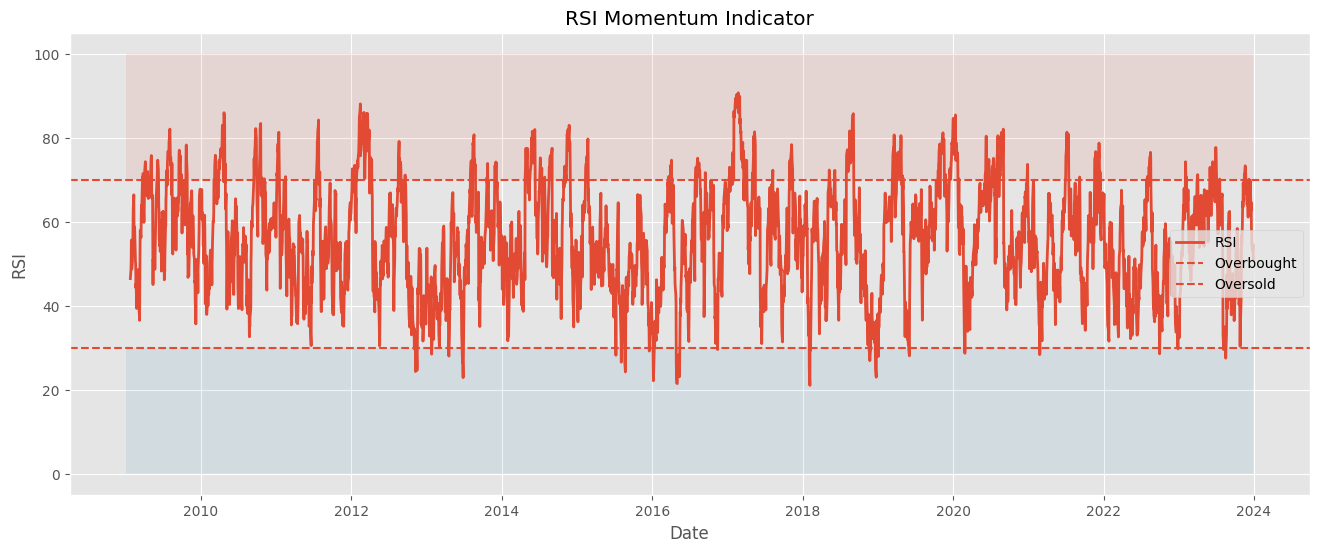

In [14]:
plt.figure(figsize=(16,6))

plt.plot(df['Date'], df['RSI'], label='RSI', linewidth=2)
plt.axhline(70, linestyle='--', label='Overbought')
plt.axhline(30, linestyle='--', label='Oversold')

plt.fill_between(df['Date'], 70, 100, alpha=0.1)
plt.fill_between(df['Date'], 0, 30, alpha=0.1)

plt.title('RSI Momentum Indicator')
plt.xlabel('Date')
plt.ylabel('RSI')
plt.legend()
plt.grid(True)
plt.show()

# MACD Momentum & Trend Reversal

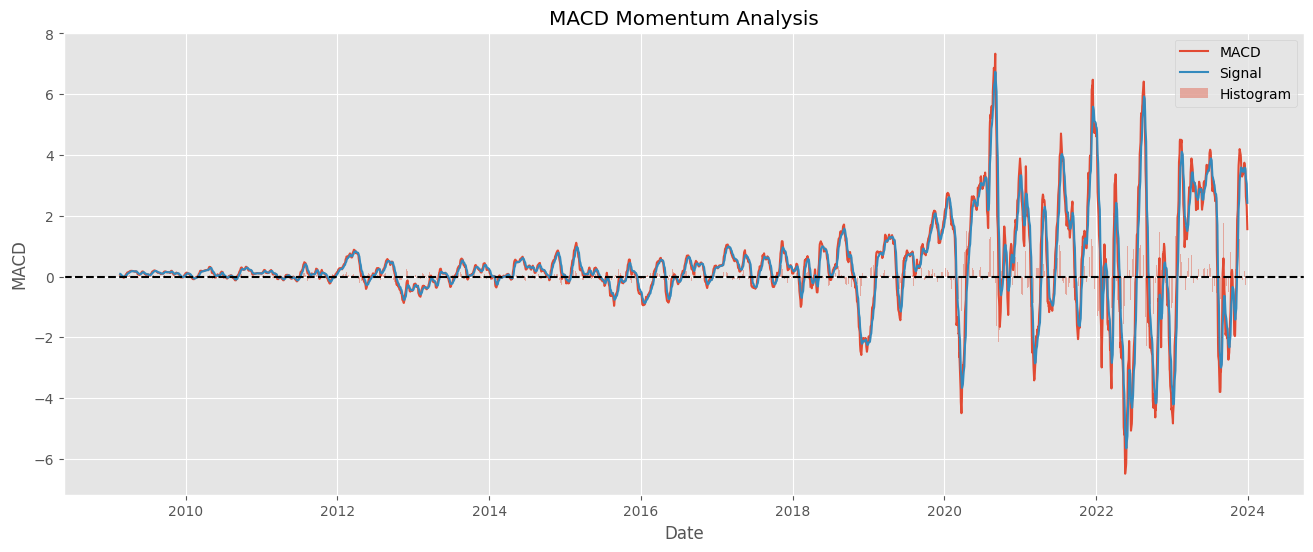

In [15]:
plt.figure(figsize=(16,6))

plt.plot(df['Date'], df['MACD'], label='MACD')
plt.plot(df['Date'], df['MACD_SIGNAL'], label='Signal')
plt.bar(df['Date'], df['MACD_HIST'], alpha=0.4, label='Histogram')

plt.axhline(0, color='black', linestyle='--')

plt.title('MACD Momentum Analysis')
plt.xlabel('Date')
plt.ylabel('MACD')
plt.legend()
plt.grid(True)
plt.show()

# Volatility vs Price Action (Dual Axis)

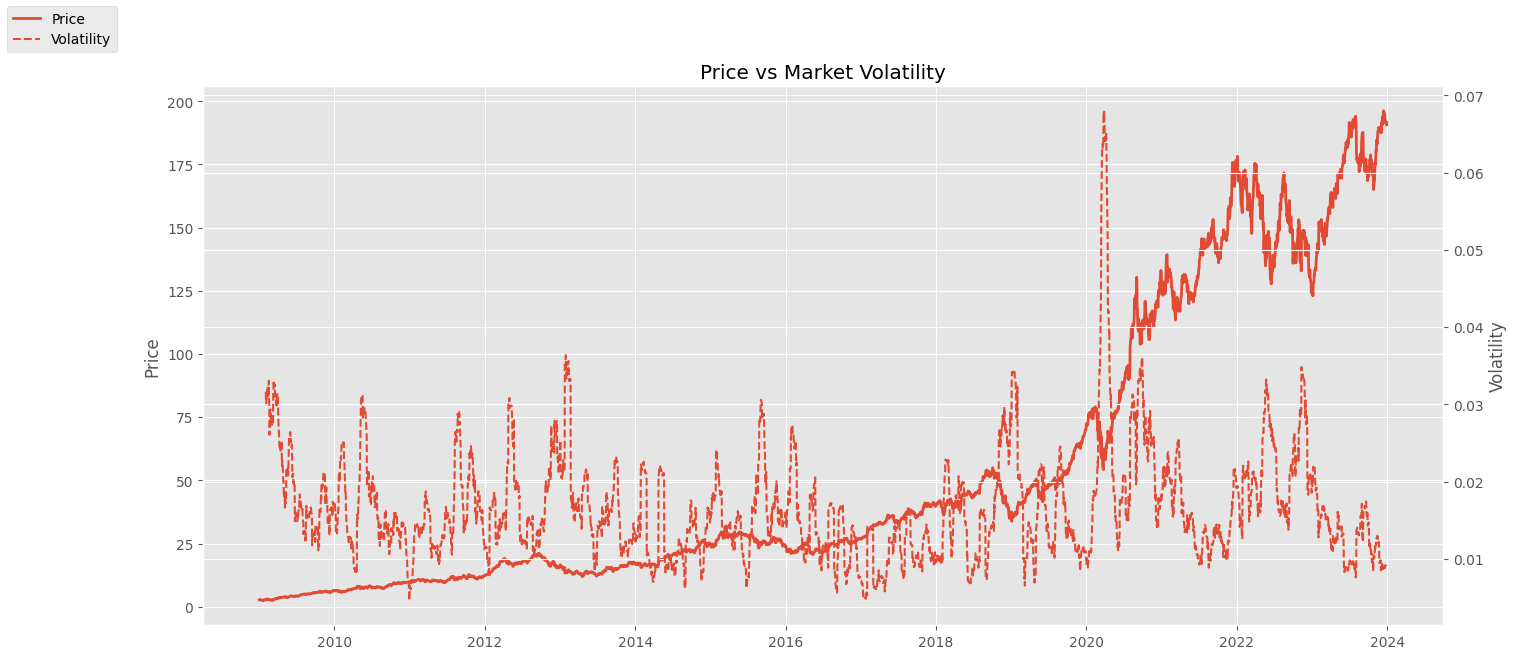

In [16]:
fig, ax1 = plt.subplots(figsize=(16,7))

ax1.plot(df['Date'], df['Close'], label='Price', linewidth=2)
ax1.set_ylabel('Price')

ax2 = ax1.twinx()
ax2.plot(df['Date'], df['Volatility'], linestyle='--', label='Volatility')
ax2.set_ylabel('Volatility')

plt.title('Price vs Market Volatility')
fig.legend(loc='upper left')
plt.grid(True)
plt.show()

# Key Insights

- Moving averages show trend direction
- RSI identifies market extremes
- MACD captures momentum shifts
- Volatility reflects uncertainty

Together, these indicators provide a complete view of market behavior.